# Importação das bibliotecas

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

from tensorflow import keras
from tensorflow.keras import layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenet
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

import os

os.makedirs("resultados", exist_ok=True)

# Importação e leitura do dataset

In [2]:
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

train_dir = os.path.join(path, "train")
test_dir = os.path.join(path, "test")

print(os.path.exists(train_dir))
print(os.path.exists(test_dir))

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013
True
True


# Configurações gerais

In [3]:
img_size = 48
batch_size = 64
num_classes = 7

# Pré-processamento e normalização para DNN e CNN

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

class_names = list(test_data.class_indices.keys())
print(class_names)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


# Visualização de algumas imagens do dataset

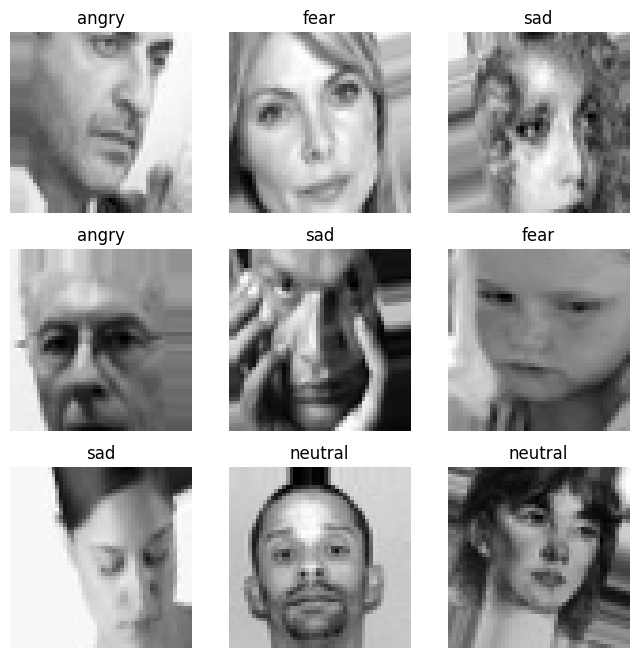

In [5]:
x_batch, y_batch = next(train_data)

plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_batch[i].reshape(img_size, img_size), cmap="gray")
    plt.title(class_names[np.argmax(y_batch[i])])
    plt.axis("off")
new_var = plt.savefig(f"resultados/.png", dpi=300, bbox_inches="tight")
new_var
plt.show()

# Construção da Rede Neural Profunda - DNN

In [ ]:
model_dnn = keras.Sequential([
    layers.Flatten(input_shape=(48, 48, 1)),
    layers.Dense(512, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model_dnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345,287 (5.13 MB)

 Trainable params: 1,345,287 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

# Compilando o modelo DNN

In [ ]:
optimizer = optimizers.Adam(learning_rate=0.001)

model_dnn.compile(
    loss="categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

# Treinando o modelo DNN

In [ ]:
history_dnn = model_dnn.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 152s 420ms/step - accuracy: 0.2396 - loss: 1.8387 - val_accuracy: 0.2538 - val_loss: 1.8018
Epoch 2/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 102s 141ms/step - accuracy: 0.2584 - loss: 1.7974 - val_accuracy: 0.2695 - val_loss: 1.7956
Epoch 3/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 43s 119ms/step - accuracy: 0.2645 - loss: 1.7853 - val_accuracy: 0.2785 - val_loss: 1.7773
Epoch 4/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 45s 125ms/step - accuracy: 0.2756 - loss: 1.7708 - val_accuracy: 0.2731 - val_loss: 1.7634
Epoch 5/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 45s 124ms/step - accuracy: 0.2861 - loss: 1.7559 - val_accuracy: 0.2674 - val_loss: 1.7979
Epoch 6/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 44s 122ms/step - accuracy: 0.2873 - loss: 1.7512 - val_accuracy: 0.2956 - val_loss: 1.7509
Epoch 7/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 44s 124ms/step - accuracy: 0.2884 - loss: 1.7493 - val_accuracy: 0.2937 - val_loss: 1.7464
Epoch 8/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 49s 137ms/step - accuracy: 0.2916 - loss:

# Avaliando o modelo DNN

In [ ]:
score_dnn = model_dnn.evaluate(test_data, verbose=1)

print("DNN - Test loss:", score_dnn[0])
print("DNN - Test accuracy:", score_dnn[1])

113/113 ━━━━━━━━━━━━━━━━━━━━ 30s 266ms/step - accuracy: 0.3476 - loss: 1.6787
DNN - Test loss: 1.6787272691726685
DNN - Test accuracy: 0.3475898504257202


# Construção da Rede Neural Convolucional - CNN

In [ ]:
model_cnn = keras.Sequential()

model_cnn.add(layers.Conv2D(
    filters=32,
    kernel_size=5,
    strides=(1,1),
    padding="same",
    activation="relu",
    input_shape=(48, 48, 1)
))

model_cnn.add(layers.MaxPooling2D(
    pool_size=(2,2),
    strides=(2,2),
    padding="valid"
))

model_cnn.add(layers.Conv2D(
    filters=64,
    kernel_size=3,
    strides=(1,1),
    padding="same",
    activation="relu"
))

model_cnn.add(layers.MaxPooling2D(
    pool_size=(2,2),
    strides=(2,2),
    padding="valid"
))

model_cnn.add(layers.Dropout(0.25))
model_cnn.add(layers.Flatten())
model_cnn.add(layers.Dense(128, activation="relu"))
model_cnn.add(layers.Dropout(0.5))
model_cnn.add(layers.Dense(num_classes, activation="softmax"))

model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,200,007 (4.58 MB)

 Trainable params: 1,200,007 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

# Compilando o modelo CNN

In [ ]:
model_cnn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Treinando o modelo CNN

In [ ]:
history_cnn = model_cnn.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 108s 296ms/step - accuracy: 0.2564 - loss: 1.7980 - val_accuracy: 0.3033 - val_loss: 1.7530
Epoch 2/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 117s 325ms/step - accuracy: 0.2913 - loss: 1.7417 - val_accuracy: 0.3155 - val_loss: 1.7095
Epoch 3/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 106s 296ms/step - accuracy: 0.3145 - loss: 1.7024 - val_accuracy: 0.3301 - val_loss: 1.6682
Epoch 4/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 109s 303ms/step - accuracy: 0.3402 - loss: 1.6678 - val_accuracy: 0.3571 - val_loss: 1.6360
Epoch 5/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 115s 320ms/step - accuracy: 0.3576 - loss: 1.6371 - val_accuracy: 0.3762 - val_loss: 1.5972
Epoch 6/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 123s 343ms/step - accuracy: 0.3667 - loss: 1.6169 - val_accuracy: 0.3766 - val_loss: 1.5864
Epoch 7/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 114s 318ms/step - accuracy: 0.3731 - loss: 1.5993 - val_accuracy: 0.3865 - val_loss: 1.5509
Epoch 8/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 116s 322ms/step - accuracy: 0.3807 -

# Avaliando o modelo CNN

In [ ]:
score_cnn = model_cnn.evaluate(test_data, verbose=1)

print("CNN - Test loss:", score_cnn[0])
print("CNN - Test accuracy:", score_cnn[1])

113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.4744 - loss: 1.3646
CNN - Test loss: 1.364585280418396
CNN - Test accuracy: 0.47436612844467163


# Pré-processamento para MobileNetV2 e ResNet50

In [6]:
img_size_transfer = 96
batch_size = 32

train_datagen_transfer = ImageDataGenerator(
    preprocessing_function=preprocess_mobilenet,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True
)

test_datagen_transfer = ImageDataGenerator(
    preprocessing_function=preprocess_mobilenet
)

train_data_transfer = train_datagen_transfer.flow_from_directory(
    train_dir,
    target_size=(img_size_transfer, img_size_transfer),
    color_mode="rgb",
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_data_transfer = train_datagen_transfer.flow_from_directory(
    train_dir,
    target_size=(img_size_transfer, img_size_transfer),
    color_mode="rgb",
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

test_data_transfer = test_datagen_transfer.flow_from_directory(
    test_dir,
    target_size=(img_size_transfer, img_size_transfer),
    color_mode="rgb",
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


# Modelo MobileNetV2

In [7]:
base_mobilenet = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96,96,3)
)

base_mobilenet.trainable = True

for layer in base_mobilenet.layers[:-30]:
    layer.trainable = False

model_mobilenet = keras.Sequential([
    layers.Input(shape=(96, 96, 3)),
    base_mobilenet,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

model_mobilenet.summary()

model_mobilenet.compile(
    optimizer=keras.optimizers.Adam(
    learning_rate=0.0001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# CALLBACKS
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7
    ),
    keras.callbacks.ModelCheckpoint(
        "melhor_mobilenet.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history_mobilenet = model_mobilenet.fit(
    train_data_transfer,
    epochs=30,
    validation_data=val_data_transfer,
    callbacks=[early_stop],
    verbose=1
)

score_mobilenet = model_mobilenet.evaluate(test_data_transfer, verbose=1)
print("MobileNetV2 - Test loss:", score_mobilenet[0])
print("MobileNetV2 - Test accuracy:", score_mobilenet[1])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,839 (9.89 MB)

 Trainable params: 1,858,695 (7.09 MB)

 Non-trainable params: 734,144 (2.80 MB)

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 358s 483ms/step - accuracy: 0.3406 - loss: 2.0280 - val_accuracy: 0.4365 - val_loss: 1.6984
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 322s 449ms/step - accuracy: 0.4313 - loss: 1.6294 - val_accuracy: 0.4747 - val_loss: 1.4768
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 323s 450ms/step - accuracy: 0.4638 - loss: 1.4696 - val_accuracy: 0.4712 - val_loss: 1.3848
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 322s 448ms/step - accuracy: 0.4910 - loss: 1.3696 - val_accuracy: 0.4978 - val_loss: 1.3371
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 324s 451ms/step - accuracy: 0.5106 - loss: 1.3111 - val_accuracy: 0.5100 - val_loss: 1.3004
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 323s 450ms/step - accuracy: 0.5339 - loss: 1.2529 - val_accuracy: 0.5445 - val_loss: 1.2482
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 321s 447ms/step - accuracy: 0.5413 - loss: 1.2152 - val_accuracy: 0.5328 - val_loss: 1.2592
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 321s 448ms/step - accuracy: 0.5600 -

In [8]:
model_mobilenet.save("modelo_mobilenetv2_emocoes.keras")

In [9]:
from google.colab import files
files.download("modelo_mobilenetv2_emocoes.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
print(train_data_transfer.class_indices)

{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [11]:
score_mobilenet = model_mobilenet.evaluate(test_data_transfer)
print(score_mobilenet)

225/225 ━━━━━━━━━━━━━━━━━━━━ 41s 181ms/step - accuracy: 0.5454 - loss: 1.2440
[1.2440171241760254, 0.545416533946991]


# Pré-processamento próprio para ResNet50

In [ ]:
train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_resnet,
    validation_split=0.2
)

test_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_resnet
)

train_data_resnet = train_datagen_resnet.flow_from_directory(
    train_dir,
    target_size=(96, 96),
    color_mode="rgb",
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_data_resnet = train_datagen_resnet.flow_from_directory(
    train_dir,
    target_size=(96, 96),
    color_mode="rgb",
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

test_data_resnet = test_datagen_resnet.flow_from_directory(
    test_dir,
    target_size=(96, 96),
    color_mode="rgb",
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


# Modelo ResNet50

In [ ]:
base_resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

base_resnet.trainable = False

model_resnet = keras.Sequential([
    layers.Input(shape=(96, 96, 3)),
    base_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

model_resnet.summary()

model_resnet.compile(
    optimizer=keras.optimizers.Adam(
    learning_rate=0.0001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_resnet = model_resnet.fit(
    train_data_resnet,
    epochs=10,
    validation_data=val_data_resnet,
    callbacks=[early_stop],
    verbose=1
)

score_resnet = model_resnet.evaluate(test_data_resnet, verbose=1)
print("ResNet50 - Test loss:", score_resnet[0])
print("ResNet50 - Test accuracy:", score_resnet[1])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,887 (90.98 MB)

 Trainable params: 263,175 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 822s 1s/step - accuracy: 0.3156 - loss: 1.8366 - val_accuracy: 0.4081 - val_loss: 1.5509
Epoch 2/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 809s 1s/step - accuracy: 0.3987 - loss: 1.5774 - val_accuracy: 0.4339 - val_loss: 1.4883
Epoch 3/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 810s 1s/step - accuracy: 0.4257 - loss: 1.5075 - val_accuracy: 0.4457 - val_loss: 1.4512
225/225 ━━━━━━━━━━━━━━━━━━━━ 199s 883ms/step - accuracy: 0.4167 - loss: 1.5413
ResNet50 - Test loss: 1.5412756204605103
ResNet50 - Test accuracy: 0.4166898727416992


# Gráficos de acurácia e perda

In [ ]:
def plot_history(history, titulo):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Treinamento")
    plt.plot(history.history["val_accuracy"], label="Validação")
    plt.title("Acurácia - " + titulo)
    plt.xlabel("Épocas")
    plt.ylabel("Acurácia")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Treinamento")
    plt.plot(history.history["val_loss"], label="Validação")
    plt.title("Perda - " + titulo)
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()

    plt.savefig(f"resultados/{titulo}.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_history(history_dnn, "DNN")
plot_history(history_cnn, "CNN")
plot_history(history_mobilenet, "MobileNetV2")
plot_history(history_resnet, "ResNet50")

NameError: name 'history_dnn' is not defined

# Função para avaliar acurácia, precisão, recall, F1-score, matriz de confusão e curva ROC

In [ ]:
def avaliar_modelo(model, test_data, nome_modelo):
    test_data.reset()

    y_prob = model.predict(test_data)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_data.classes

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print("=" * 50)
    print("Resultados do modelo:", nome_modelo)
    print(f"Acurácia: {acc:.4f}")
    print(f"Precisão: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    print("\nRelatório de classificação:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(cmap="Blues", xticks_rotation=45, ax=ax)
    plt.title("Matriz de Confusão - " + nome_modelo)

    plt.savefig(f"resultados/{nome_modelo}_matriz_confusao.png",
                dpi=300,
                bbox_inches="tight")

    plt.show()

    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

    plt.figure(figsize=(10, 8))

    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} - AUC = {roc_auc:.2f}")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("Falso Positivo")
    plt.ylabel("Verdadeiro Positivo")
    plt.title("Curva ROC Multiclasse - " + nome_modelo)
    plt.legend()

    plt.savefig(f"resultados/{nome_modelo}_curva_roc.png",
                dpi=300,
                bbox_inches="tight")

    plt.show()

    return {
        "Modelo": nome_modelo,
        "Acurácia": acc,
        "Precisão": precision,
        "Recall": recall,
        "F1-score": f1
    }

# Avaliação completa dos modelos

113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step
Resultados do modelo: DNN
Acurácia: 0.3272
Precisão: 0.2938
Recall: 0.2381
F1-score: 0.1979

Relatório de classificação:
              precision    recall  f1-score   support

       angry       0.33      0.02      0.03       958
     disgust       0.00      0.00      0.00       111
        fear       0.33      0.00      0.00      1024
       happy       0.32      0.86      0.46      1774
     neutral       0.28      0.22      0.25      1233
         sad       0.36      0.15      0.21      1247
    surprise       0.44      0.42      0.43       831

    accuracy                           0.33      7178
   macro avg       0.29      0.24      0.20      7178
weighted avg       0.33      0.33      0.25      7178



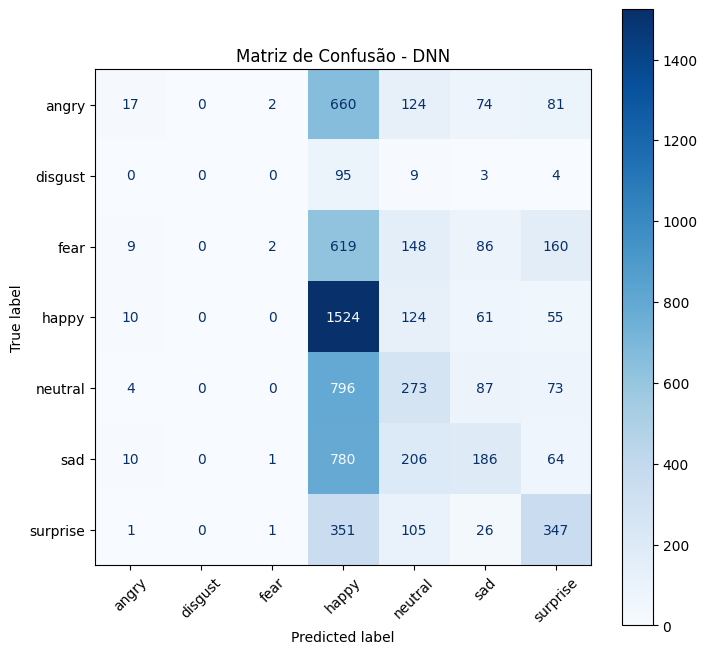

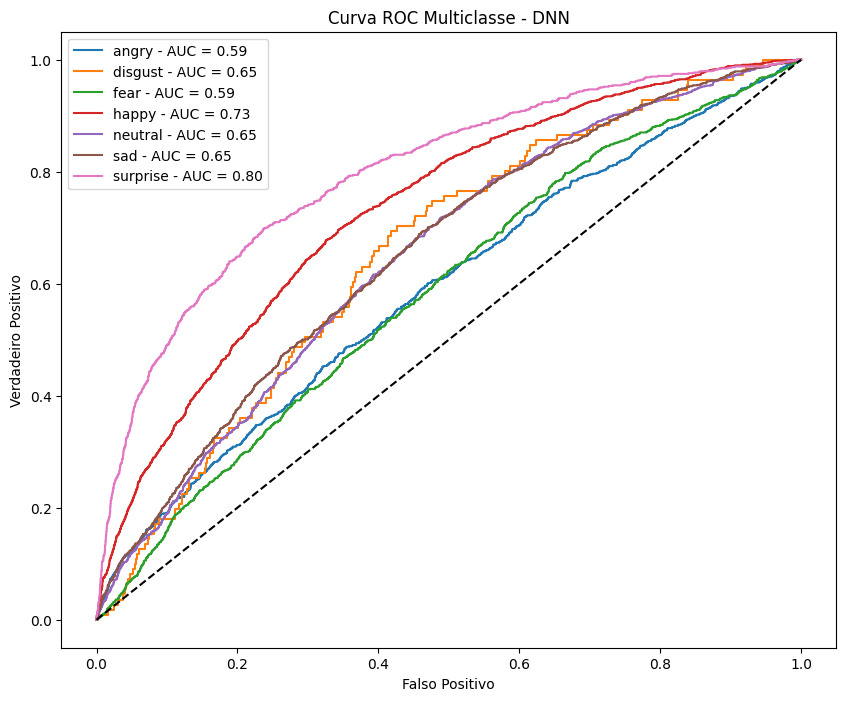

113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step
Resultados do modelo: CNN
Acurácia: 0.4696
Precisão: 0.3711
Recall: 0.3855
F1-score: 0.3624

Relatório de classificação:
              precision    recall  f1-score   support

       angry       0.31      0.39      0.34       958
     disgust       0.00      0.00      0.00       111
        fear       0.28      0.12      0.17      1024
       happy       0.58      0.82      0.68      1774
     neutral       0.42      0.51      0.46      1233
         sad       0.44      0.19      0.27      1247
    surprise       0.57      0.66      0.61       831

    accuracy                           0.47      7178
   macro avg       0.37      0.39      0.36      7178
weighted avg       0.44      0.47      0.43      7178



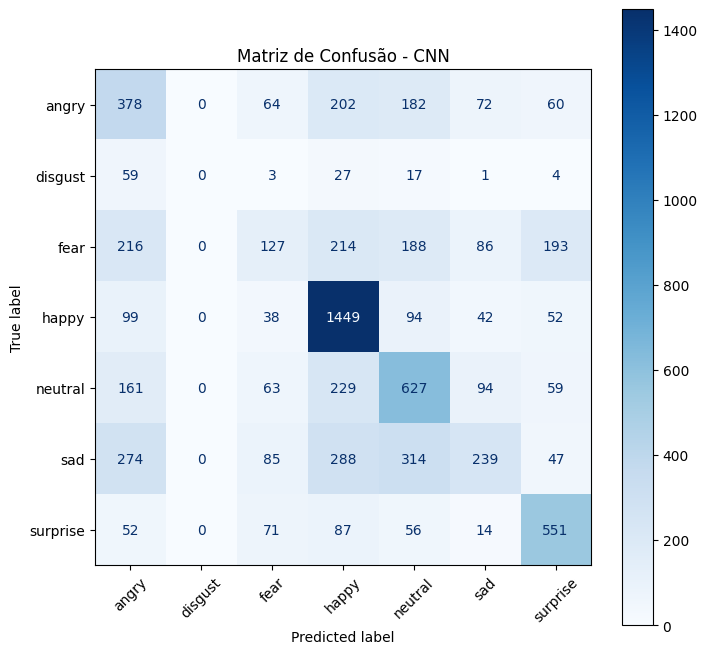

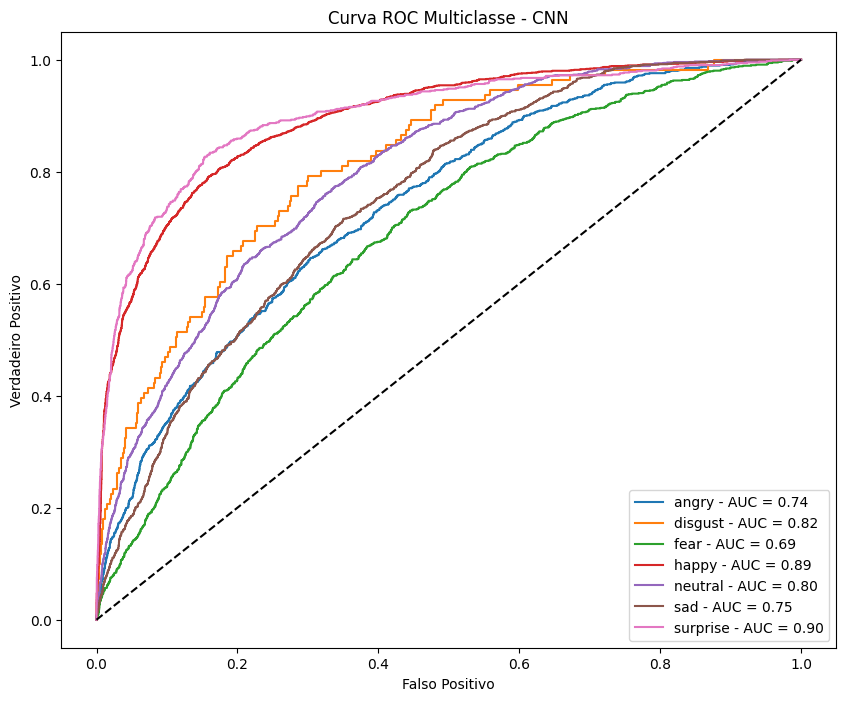

225/225 ━━━━━━━━━━━━━━━━━━━━ 54s 234ms/step
Resultados do modelo: MobileNetV2
Acurácia: 0.5564
Precisão: 0.6331
Recall: 0.4812
F1-score: 0.4858

Relatório de classificação:
              precision    recall  f1-score   support

       angry       0.48      0.42      0.45       958
     disgust       1.00      0.06      0.12       111
        fear       0.52      0.29      0.37      1024
       happy       0.84      0.67      0.75      1774
     neutral       0.42      0.73      0.53      1233
         sad       0.44      0.50      0.47      1247
    surprise       0.73      0.70      0.71       831

    accuracy                           0.56      7178
   macro avg       0.63      0.48      0.49      7178
weighted avg       0.60      0.56      0.55      7178



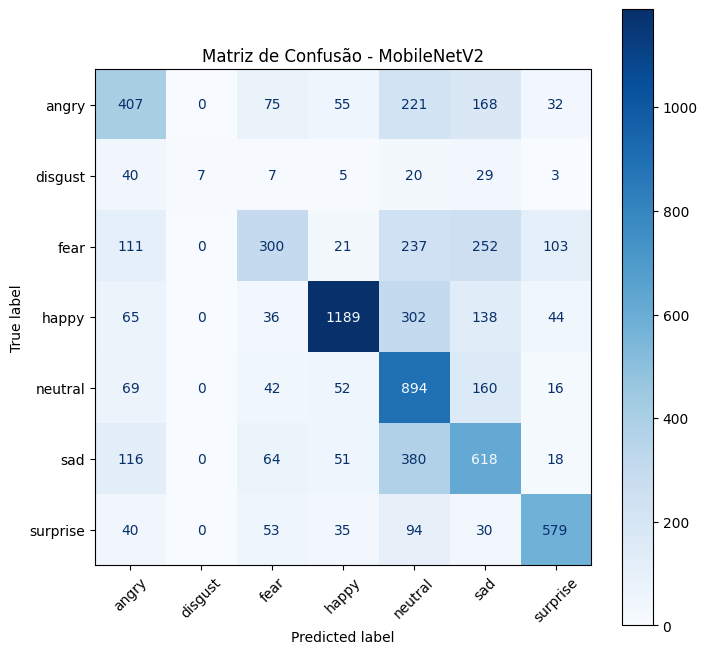

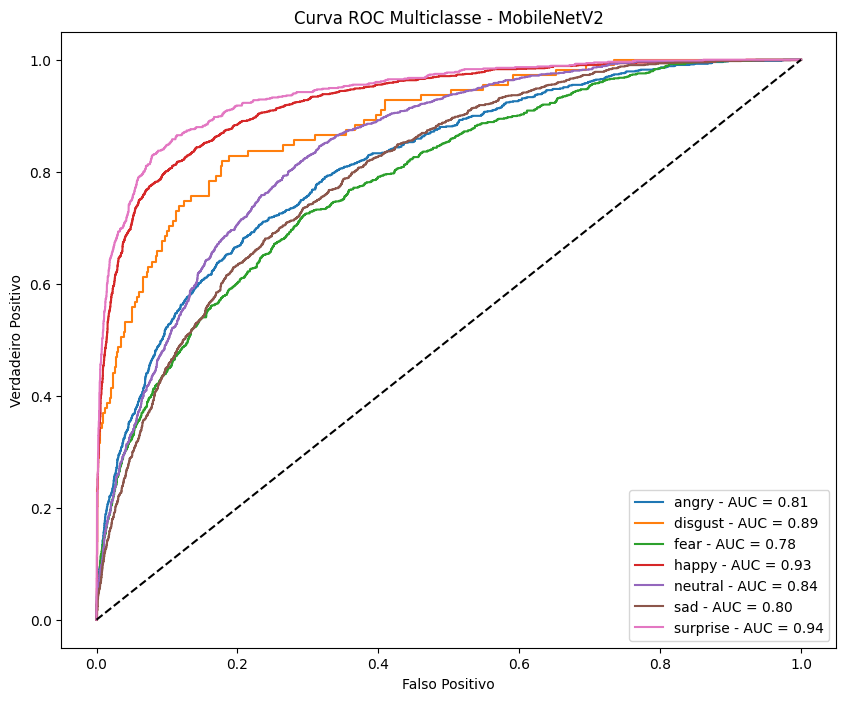

225/225 ━━━━━━━━━━━━━━━━━━━━ 207s 909ms/step
Resultados do modelo: ResNet50
Acurácia: 0.4167
Precisão: 0.3348
Recall: 0.3338
F1-score: 0.3178

Relatório de classificação:
              precision    recall  f1-score   support

       angry       0.29      0.18      0.22       958
     disgust       0.00      0.00      0.00       111
        fear       0.31      0.11      0.16      1024
       happy       0.46      0.74      0.57      1774
     neutral       0.41      0.27      0.33      1233
         sad       0.35      0.47      0.40      1247
    surprise       0.52      0.56      0.54       831

    accuracy                           0.42      7178
   macro avg       0.33      0.33      0.32      7178
weighted avg       0.39      0.42      0.38      7178



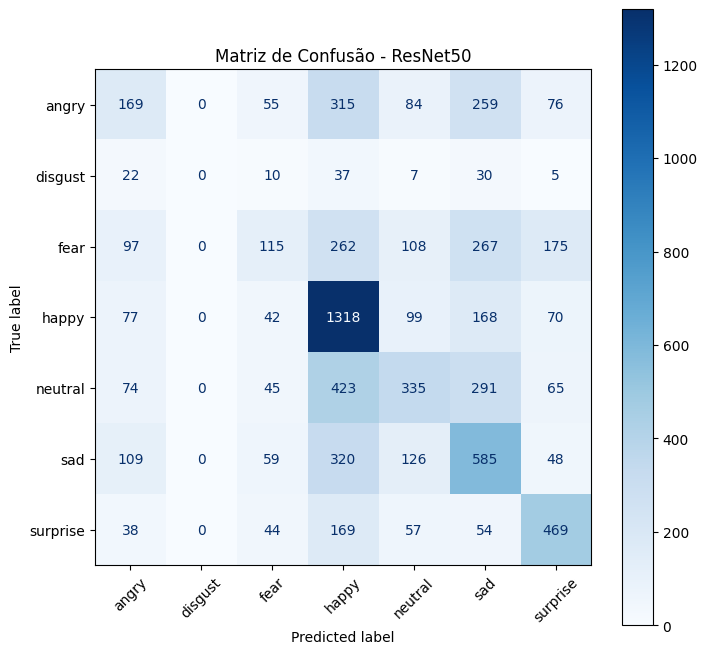

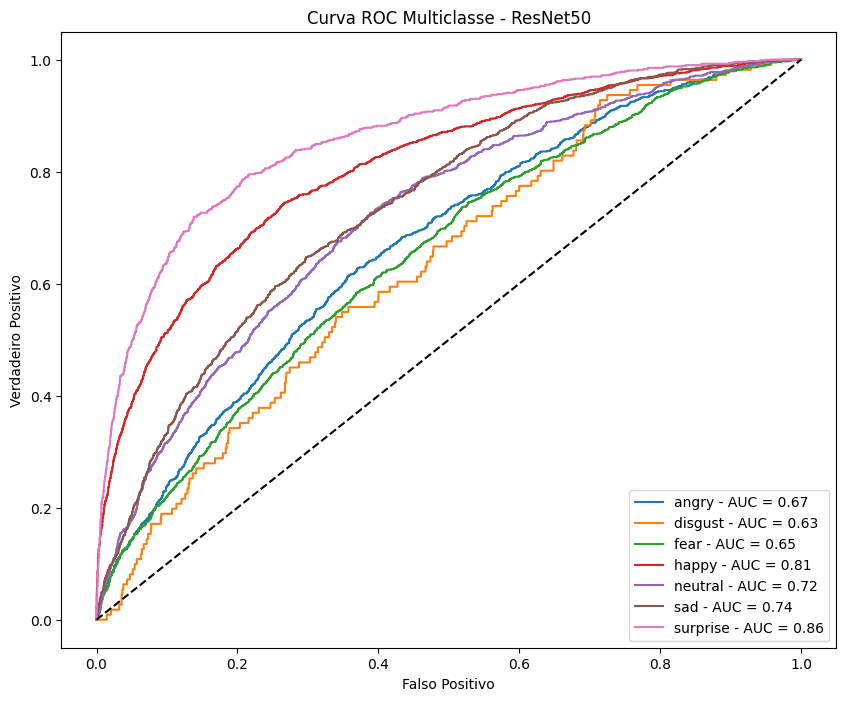

In [ ]:
resultado_dnn = avaliar_modelo(model_dnn, test_data, "DNN")
resultado_cnn = avaliar_modelo(model_cnn, test_data, "CNN")
resultado_mobilenet = avaliar_modelo(model_mobilenet, test_data_transfer, "MobileNetV2")
resultado_resnet = avaliar_modelo(model_resnet, test_data_resnet, "ResNet50")

# Tabela comparativa final

In [ ]:
import pandas as pd

resultados = pd.DataFrame([
    resultado_dnn,
    resultado_cnn,
    resultado_mobilenet,
    resultado_resnet
])

resultados

,Modelo,Acurácia,Precisão,Recall,F1-score
0,DNN,0.327250,0.293829,0.238130,0.197869
1,CNN,0.469629,0.371137,0.385518,0.362442
2,MobileNetV2,0.556422,0.633122,0.481216,0.485757
3,ResNet50,0.416690,0.334769,0.333838,0.317772


# Gráfico comparativo final

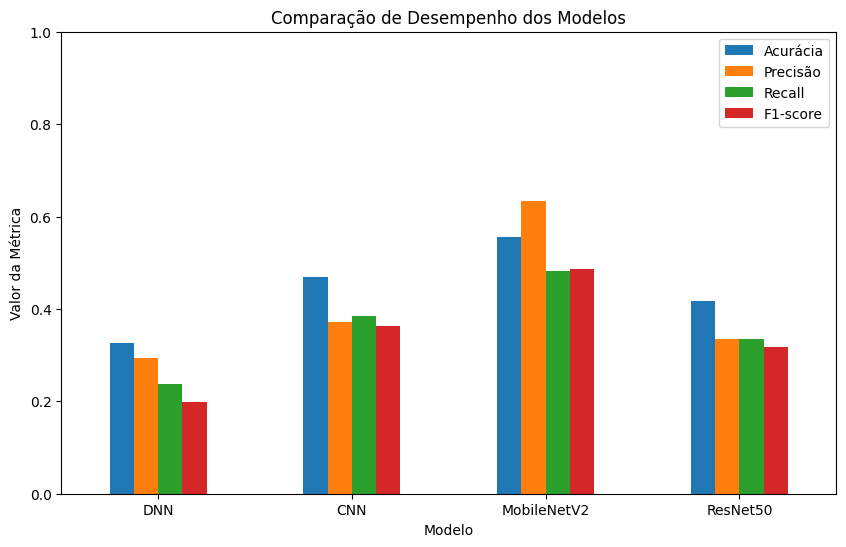

In [ ]:
resultados.set_index("Modelo")[["Acurácia", "Precisão", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparação de Desempenho dos Modelos")
plt.ylabel("Valor da Métrica")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.savefig(f"resultados/.png", dpi=300, bbox_inches="tight")
plt.show()